# **Meeting 4 — Supervised Learning for Economics**
## Bitcoin Price Prediction with Regression

**Course:** Introduction to Data Science for Economics  
**Level:** Beginner Economics Students  
**Case Study:** Bitcoin / Blockchain Economics

### Main question

> **Can we use historical Bitcoin market data to predict the next 7 trading-day closing prices?**

### What we will learn

1. What is **Supervised Learning**?
2. Common algorithms used in supervised learning.
3. Mathematical formulas for regression algorithms.
4. Regression in macroeconomic and microeconomic problems.
5. **Training, Validation, and Testing**.
6. **Ridge Regression and Lasso Regression**.
7. Implementation: **Bitcoin price prediction**.

### Important

Yes, **Linear Regression can be used as a simple educational approach to predict Bitcoin prices**.

However, Bitcoin is highly volatile and financial prices are difficult to predict. Therefore, this notebook is a **learning demonstration**, not an investment recommendation.

### Connection with the previous meeting

Previous meeting:

**EDA → Visualization → Correlation → Feature Engineering**

This meeting:

**Features → Supervised Learning → Regression → Evaluation → 7-Day Forecast**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. What is Supervised Learning?

**Supervised Learning** is a Machine Learning approach where we learn a relationship between:

- **Input / Features (X)**
- **Target / Output (y)**

The model learns from historical examples where the target is already known.

### Simple example

If we want to predict Bitcoin's closing price:

**Features (X):**
- Previous-day price
- 3-day moving average
- 7-day moving average
- Previous-day return
- Trading volume

**Target (y):**
- Today's closing price

The model learns:

> **Historical features → Historical price**

Then we use the learned relationship to estimate future prices.

### In economics

The same idea can be used for:

**Economic indicators → GDP growth**

**Household characteristics → Household expenditure**

**Interest rates + inflation → Investment**

**Historical asset information → Asset price**


# 2. Regression vs Classification

Supervised Learning is commonly divided into:

### Regression
The target is a **continuous numerical value**.

Examples:
- Predict GDP
- Predict income
- Predict inflation
- Predict house prices
- Predict Bitcoin price

### Classification
The target is a **category/class**.

Examples:
- Recession vs no recession
- Default vs no default
- High-risk vs low-risk

### Our case

Bitcoin price is numerical, so this is a:

> **Regression problem**


# 3. Common Supervised Learning Regression Algorithms

We will introduce several algorithms:

### 1. Linear Regression
Assumes a linear relationship between features and target.

### 2. Polynomial Regression
Extends linear regression by allowing curved relationships.

### 3. Ridge Regression
Linear regression with **L2 regularization**.

### 4. Lasso Regression
Linear regression with **L1 regularization**.

### 5. Decision Tree Regression
Uses a sequence of rules to divide observations into groups.

### 6. Random Forest Regression
Combines many decision trees to improve prediction.

> For today's beginner implementation, we will focus mainly on **Linear Regression, Ridge, and Lasso**.


# 4. Mathematical Formula — Linear Regression

For one feature:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

Where:

- $\hat{y}$ = predicted value
- $\beta_0$ = intercept
- $\beta_1$ = coefficient
- $x$ = input feature

For multiple features:

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
$$


</br>

### Economic interpretation

Suppose:

$$
\text{Bitcoin Price} = \beta_0 + \beta_1 \text{Volume} + \beta_2 \text{MA}_7
$$



Each coefficient describes the model's estimated relationship between a feature and Bitcoin price, **holding the other included features constant**.

# 5. Mathematical Formula — Polynomial Regression

Polynomial regression adds powers of the features.

For one feature:

$$
\hat{y}
=
\beta_0
+
\beta_1 x
+
\beta_2 x^2
+
\beta_3 x^3
+
\cdots
$$

This allows the model to represent a **curved relationship**.

### Example

Instead of:

$$
\text{Price} = \beta_0 + \beta_1(\text{Return})
$$

we could have:

$$
\text{Price}
=
\beta_0
+
\beta_1(\text{Return})
+
\beta_2(\text{Return})^2
$$

The important idea is that polynomial regression is still estimated using regression, but the feature representation includes powers of the original variables.

# 6. Mathematical Formula — Ridge Regression

Ridge regression adds an **L2 penalty** to the regression objective.

$$
\min_{\beta}
\left[
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
+
\lambda\sum_{j=1}^{p}\beta_j^2
\right]
$$

Where:

- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $\beta_j$ = regression coefficient
- $\lambda$ = regularization strength

### Simple interpretation

Ridge says:

> "Fit the data, but discourage very large coefficients."

This can help reduce **overfitting**, especially when features are correlated.

# 7. Mathematical Formula — Lasso Regression

Lasso regression adds an **L1 penalty**:

$$
\min_{\beta}
\left[
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
+
\lambda\sum_{j=1}^{p}|\beta_j|
\right]
$$

The important difference is:

### Ridge

Uses:

$$
\beta_j^2
$$

### Lasso

Uses:

$$
|\beta_j|
$$

Lasso can shrink some coefficients exactly to **zero**.

Therefore, Lasso can also perform a type of **feature selection**.

# 8. Decision Tree & Random Forest Regression

### Decision Tree Regression

A decision tree repeatedly splits observations according to rules.

Example:

> Is previous return < 0.02?

Then:

> Is trading volume > a certain level?

The final group produces a predicted value.

### Random Forest Regression

A random forest builds many decision trees and combines their predictions.

Conceptually:

**Tree 1 → prediction**

**Tree 2 → prediction**

**Tree 3 → prediction**

...

**Many trees → combined prediction**

These methods can capture nonlinear patterns, but they are more difficult to explain than a simple linear regression.

For this introductory class, we focus on Linear, Ridge, and Lasso.


# 9. Regression in Economics

Regression is widely used in both **macroeconomics** and **microeconomics**.

### Macroeconomic examples

**GDP growth** ← interest rate + inflation + government spending

**Inflation** ← money supply + exchange rate + commodity prices

**Unemployment** ← GDP growth + investment + labor-market variables

### Microeconomic examples

**Household consumption** ← income + household size + age

**Housing price** ← income + location + house size

**Demand** ← price + income + consumer characteristics

### Financial/economic example

**Asset price/return** ← previous price + volume + market indicators

The same supervised-learning concept can be applied, but the goal and interpretation may differ.


# 10. Training, Validation, and Testing

A Machine Learning model should be evaluated on data that it did not use to learn.

### Training data
Used to **learn the model**.

### Validation data
Used to **compare models or tune parameters**.

### Test data
Used at the end to provide an **unbiased final evaluation**.

### For time-series data

We should **not randomly shuffle** observations.

Why?

Because the future should not be allowed to influence the past.

Instead:

**Past → Training**

**Later period → Validation**

**Most recent period → Testing**

This preserves the time order.


# 11. Why We Need a Time-Based Split

Imagine our data looks like this:

| Period | Use |
|---|---|
| January–June | Training |
| July | Validation |
| August | Testing |

This is more realistic than randomly mixing January, July, and August.

### Why?

If we are predicting the future:

> We should train using information that would actually have been available at that time.

This is especially important for financial and economic time-series data.


# 12. Install and Import Libraries

We will use:

- `kagglehub` → obtain the Bitcoin dataset
- `pandas` → data manipulation
- `numpy` → calculations
- `matplotlib` → visualization
- `seaborn` → visualization
- `scikit-learn` → regression and evaluation


In [1]:
# Install KaggleHub so Google Colab can download the public Kaggle dataset.
!pip -q install kagglehub

# Import pandas for working with tabular data.
import pandas as pd

# Import numpy for numerical calculations.
import numpy as np

# Import matplotlib for charts.
import matplotlib.pyplot as plt

# Import seaborn for statistical visualization.
import seaborn as sns

# Import kagglehub for downloading the Kaggle dataset.
import kagglehub

# Import LinearRegression for ordinary linear regression.
from sklearn.linear_model import LinearRegression

# Import Ridge for Ridge regression.
from sklearn.linear_model import Ridge

# Import Lasso for Lasso regression.
from sklearn.linear_model import Lasso

# Import metrics for evaluating regression models.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import StandardScaler because Ridge and Lasso are sensitive to feature scale.
from sklearn.preprocessing import StandardScaler

# Set a simple style for our charts.
sns.set_theme(style="whitegrid")

# Print a message so students know the libraries are ready.
print("Libraries are ready!")


Libraries are ready!


# 13. Download the Bitcoin Dataset

We use the same type of dataset as the previous EDA meeting.

The dataset contains historical Bitcoin market information.

We will use the data to create features and predict the closing price.


In [2]:
# Download the public Bitcoin dataset from Kaggle.
dataset_path = kagglehub.dataset_download("priyamchoksi/bitcoin-historical-prices-and-activity-2010-2024")

# Print the location of the downloaded dataset.
print("Dataset location:", dataset_path)

# Find all CSV files inside the downloaded dataset folder.
import glob

# Search recursively for CSV files.
csv_files = glob.glob(dataset_path + "/**/*.csv", recursive=True)

# Print the files that were found.
print("CSV files found:")

# Loop through each CSV file.
for file in csv_files:

    # Print the CSV file path.
    print(file)


100%|██████████| 378k/378k [00:00<00:00, 70.6MB/s]

Extracting files...
Dataset location: /root/.cache/kagglehub/datasets/priyamchoksi/bitcoin-historical-prices-and-activity-2010-2024/versions/4
CSV files found:
/root/.cache/kagglehub/datasets/priyamchoksi/bitcoin-historical-prices-and-activity-2010-2024/versions/4/bitcoin_2010-07-17_2024-05-23.csv
/root/.cache/kagglehub/datasets/priyamchoksi/bitcoin-historical-prices-and-activity-2010-2024/versions/4/bitcoin_2010-07-17_2024-06-28.csv


In [3]:
# Check that at least one CSV file was found.
if len(csv_files) == 0:

    # Stop the notebook if no CSV file was found.
    raise FileNotFoundError("No CSV file was found.")

# Select the first CSV file.
csv_file = csv_files[0]

# Read the CSV file into a pandas DataFrame.
df = pd.read_csv(csv_file)

# Display the first five rows.
display(df.head())


,Start,End,Open,High,Low,Close,Volume,Market Cap
0,2024-05-22,2024-05-23,70144.69,70599.97,69048.60,69224.99,1.161000e+11,1.375970e+12
1,2024-05-21,2024-05-22,71369.73,71739.14,69266.38,70104.40,1.403673e+11,1.391372e+12
2,2024-05-20,2024-05-21,66222.45,71456.55,66139.62,71418.17,9.769064e+10,1.332128e+12
3,2024-05-19,2024-05-20,66972.63,67598.31,66005.33,66347.05,8.441685e+10,1.317072e+12
4,2024-05-18,2024-05-19,66939.82,67376.41,66640.01,66914.58,9.377570e+10,1.318743e+12


# 14. Prepare the Dataset

Different versions of a dataset can use different column names.

We will standardize the names and identify the variables needed for prediction.


In [4]:
# Create a copy so we can safely modify the data.
data = df.copy()

# Convert all column names to lowercase.
data.columns = [str(column).lower().strip() for column in data.columns]

# Display the standardized column names.
print(data.columns.tolist())

# Create a list of possible date-column names.
possible_date_columns = ["date", "start", "datetime", "timestamp"]

# Find the first matching date column.
date_column = next((column for column in possible_date_columns if column in data.columns), None)

# Stop if no date column can be found.
if date_column is None:

    # Raise an informative error.
    raise ValueError("A date column could not be identified.")

# Convert the date column into datetime format.
data[date_column] = pd.to_datetime(data[date_column], errors="coerce")

# Remove rows where the date could not be converted.
data = data.dropna(subset=[date_column])

# Sort the data chronologically.
data = data.sort_values(date_column).reset_index(drop=True)

# Print the available date range.
print("Start date:", data[date_column].min())

# Print the final available date.
print("End date:", data[date_column].max())


['start', 'end', 'open', 'high', 'low', 'close', 'volume', 'market cap']
Start date: 2010-07-17 00:00:00
End date: 2024-05-22 00:00:00


In [5]:
# Create a helper function to find common variable names.
def find_column(possible_names):

    # Check each possible column name.
    for name in possible_names:

        # Return the name if it exists.
        if name in data.columns:

            # Return the matching column.
            return name

    # Return None if no matching column exists.
    return None

# Find the Bitcoin price column.
price_col = find_column(["price", "close", "closing_price"])

# Find the volume column.
volume_col = find_column(["volume", "vol"])

# Find the high-price column.
high_col = find_column(["high"])

# Find the low-price column.
low_col = find_column(["low"])

# Print the columns we found.
print("Price column:", price_col)

# Print the volume column.
print("Volume column:", volume_col)

# Print the high-price column.
print("High column:", high_col)

# Print the low-price column.
print("Low column:", low_col)


Price column: close
Volume column: volume
High column: high
Low column: low


# 15. Create Prediction Features

To predict today's Bitcoin price, we should only use information that would have been available **before today**.

We will create:

- `lag_1` → previous day's price
- `lag_2` → price two observations ago
- `lag_3` → price three observations ago
- `ma_3` → 3-day moving average
- `ma_7` → 7-day moving average
- `return_1` → previous day's return
- `volume` → trading volume, if available

### Why lag variables?

Because:

> **Past information → Future prediction**

We must avoid using today's price itself as an input to predict today's price.


In [6]:
# Check that a price column exists.
if price_col is None:

    # Stop the notebook if price data is unavailable.
    raise ValueError("A price column could not be identified.")

# Create the previous day's Bitcoin price.
data["lag_1"] = data[price_col].shift(1)

# Create the price from two observations ago.
data["lag_2"] = data[price_col].shift(2)

# Create the price from three observations ago.
data["lag_3"] = data[price_col].shift(3)

# Create a three-observation moving average.
data["ma_3"] = data[price_col].rolling(window=3).mean()

# Create a seven-observation moving average.
data["ma_7"] = data[price_col].rolling(window=7).mean()

# Create the previous day's return.
data["return_1"] = data[price_col].pct_change().shift(1)

# Display the new features.
display(data[[price_col, "lag_1", "lag_2", "lag_3", "ma_3", "ma_7", "return_1"]].tail(10))


,close,lag_1,lag_2,lag_3,ma_3,ma_7,return_1
5049,62917.18,61549.96,60784.24,60887.95,61750.460000,61835.688571,0.012597
5050,61602.22,62917.18,61549.96,60784.24,62023.120000,61724.515714,0.022213
5051,66247.62,61602.22,62917.18,61549.96,63589.006667,62442.740000,-0.020900
5052,65249.97,66247.62,61602.22,62917.18,64366.603333,62748.448571,0.075410
5053,67004.04,65249.97,66247.62,61602.22,66167.210000,63622.175714,-0.015059
5054,66914.58,67004.04,65249.97,66247.62,66389.530000,64497.938571,0.026882
5055,66347.05,66914.58,67004.04,65249.97,66755.223333,65183.237143,-0.001335
5056,71418.17,66347.05,66914.58,67004.04,68226.600000,66397.664286,-0.008481
5057,70104.40,71418.17,66347.05,66914.58,69289.873333,67612.261429,0.076433
5058,69224.99,70104.40,71418.17,66347.05,70249.186667,68037.600000,-0.018395


# 16. Select Features

We will use:

**Core features**
- Lag 1
- Lag 2
- Lag 3
- MA 3
- MA 7
- Previous return

If trading volume exists, we will also include it.

### Target

Our target is:

**Today's Bitcoin closing price**


In [7]:
# Create the initial feature list.
features = ["lag_1", "lag_2", "lag_3", "ma_3", "ma_7", "return_1"]

# Add trading volume if the dataset contains it.
if volume_col is not None:

    # Add volume to the feature list.
    features.append(volume_col)

# Create the target variable name.
target = price_col

# Display the selected features.
print("Features:", features)

# Display the target.
print("Target:", target)


Features: ['lag_1', 'lag_2', 'lag_3', 'ma_3', 'ma_7', 'return_1', 'volume']
Target: close


# 17. Remove Rows with Missing Feature Values

Lag and moving-average calculations naturally create missing values at the beginning of the dataset.

For this classroom example, we remove those rows.


In [8]:
# Keep only the columns needed for our prediction problem.
model_data = data[features + [target]].copy()

# Remove rows containing missing values.
model_data = model_data.dropna()

# Display the number of usable observations.
print("Usable observations:", len(model_data))

# Display the first five observations.
display(model_data.head())


Usable observations: 5053


,lag_1,lag_2,lag_3,ma_3,ma_7,return_1,volume,close
6,0.0505,0.0792,0.0747,0.064100,0.069086,-0.362374,0.0,0.0626
7,0.0626,0.0505,0.0792,0.055867,0.069729,0.239604,0.0,0.0545
8,0.0545,0.0626,0.0505,0.055867,0.064686,-0.129393,0.0,0.0505
9,0.0505,0.0545,0.0626,0.053667,0.061143,-0.073394,0.0,0.0560
10,0.0560,0.0505,0.0545,0.055500,0.059043,0.108911,0.0,0.0600


# 18. Create Training, Validation, and Testing Sets

We use a **chronological split**.

For this demonstration:

- First **70%** → Training
- Next **15%** → Validation
- Final **15%** → Testing

### Important

The observations remain in chronological order.

We do **not** randomly shuffle the data.


In [9]:
# Calculate the index for the end of the training period.
train_end = int(len(model_data) * 0.70)

# Calculate the index for the end of the validation period.
validation_end = int(len(model_data) * 0.85)

# Create the training dataset.
train_data = model_data.iloc[:train_end]

# Create the validation dataset.
validation_data = model_data.iloc[train_end:validation_end]

# Create the testing dataset.
test_data = model_data.iloc[validation_end:]

# Print the number of observations in each dataset.
print("Training observations:", len(train_data))

# Print the validation size.
print("Validation observations:", len(validation_data))

# Print the testing size.
print("Testing observations:", len(test_data))


Training observations: 3537
Validation observations: 758
Testing observations: 758


In [10]:
# Create the training features.
X_train = train_data[features]

# Create the training target.
y_train = train_data[target]

# Create the validation features.
X_validation = validation_data[features]

# Create the validation target.
y_validation = validation_data[target]

# Create the testing features.
X_test = test_data[features]

# Create the testing target.
y_test = test_data[target]

# Display the date ranges represented by the three datasets.
print("Training period:", train_data.index.min(), "to", train_data.index.max())

# Print validation information.
print("Validation period:", validation_data.index.min(), "to", validation_data.index.max())

# Print testing information.
print("Testing period:", test_data.index.min(), "to", test_data.index.max())


Training period: 6 to 3542
Validation period: 3543 to 4300
Testing period: 4301 to 5058


# 19. Train Model 1 — Linear Regression

Linear Regression will be our baseline model.

The model learns:

\[
Price_t =
eta_0 +
eta_1Lag1_t +
eta_2Lag2_t +
\cdots
\]

We will first train it using the training dataset.


In [11]:
# Create a Linear Regression model.
linear_model = LinearRegression()

# Train the model using the training data.
linear_model.fit(X_train, y_train)

# Predict Bitcoin prices for the validation period.
linear_validation_prediction = linear_model.predict(X_validation)

# Print the model coefficient values.
print("Linear Regression coefficients:")

# Display the coefficients together with their feature names.
for feature, coefficient in zip(features, linear_model.coef_):

    # Print each feature and its coefficient.
    print(feature, "=", coefficient)


Linear Regression coefficients:
lag_1 = -1.000000000578159
lag_2 = -1.0000000000162657
lag_3 = 1.1768150658275379e-11
ma_3 = 2.999999999982303
ma_7 = -2.9517141920611014e-11
return_1 = 1.0240306053932701e-08
volume = 0.0


# 20. Evaluate the Linear Regression Model

We will use:

### MAE — Mean Absolute Error

$$
MAE =
\frac{1}{n}
\sum_{i=1}^{n}
\left|y_i-\hat{y}_i\right|
$$

### RMSE — Root Mean Squared Error

$$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
}
$$

### R² — Coefficient of Determination

$$
R^2 =
1 -
\frac{
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
}{
\sum_{i=1}^{n}
\left(y_i-\bar{y}\right)^2
}
$$

For price prediction, **MAE and RMSE are especially easy to interpret because they are expressed in the same unit as the target price**.

In [12]:
# Calculate the validation Mean Absolute Error.
linear_mae = mean_absolute_error(y_validation, linear_validation_prediction)

# Calculate the validation Root Mean Squared Error.
linear_rmse = np.sqrt(mean_squared_error(y_validation, linear_validation_prediction))

# Calculate the validation R-squared.
linear_r2 = r2_score(y_validation, linear_validation_prediction)

# Print the validation MAE.
print("Linear Regression Validation MAE:", linear_mae)

# Print the validation RMSE.
print("Linear Regression Validation RMSE:", linear_rmse)

# Print the validation R-squared.
print("Linear Regression Validation R²:", linear_r2)


Linear Regression Validation MAE: 1.9614564059571365e-05
Linear Regression Validation RMSE: 2.2689156433131865e-05
Linear Regression Validation R²: 1.0


# 21. Train Model 2 — Ridge Regression

Ridge regression is useful when features are correlated.

This can happen here because:

- Lag 1
- Lag 2
- Lag 3
- MA 3
- MA 7

are all related to recent Bitcoin prices.

### Important

Ridge uses **L2 regularization**.

We need to scale the features first because regularization is sensitive to feature magnitude.


In [13]:
# Create a StandardScaler object.
scaler = StandardScaler()

# Learn the scaling parameters using only the training data.
X_train_scaled = scaler.fit_transform(X_train)

# Apply the training scaling parameters to the validation data.
X_validation_scaled = scaler.transform(X_validation)

# Create a Ridge regression model.
ridge_model = Ridge(alpha=1.0)

# Train the Ridge model using scaled training data.
ridge_model.fit(X_train_scaled, y_train)

# Predict the validation period.
ridge_validation_prediction = ridge_model.predict(X_validation_scaled)

# Calculate the Ridge validation MAE.
ridge_mae = mean_absolute_error(y_validation, ridge_validation_prediction)

# Calculate the Ridge validation RMSE.
ridge_rmse = np.sqrt(mean_squared_error(y_validation, ridge_validation_prediction))

# Calculate the Ridge validation R-squared.
ridge_r2 = r2_score(y_validation, ridge_validation_prediction)

# Print the Ridge results.
print("Ridge Validation MAE:", ridge_mae)

# Print the Ridge RMSE.
print("Ridge Validation RMSE:", ridge_rmse)

# Print the Ridge R-squared.
print("Ridge Validation R²:", ridge_r2)


Ridge Validation MAE: 411.18823713300105
Ridge Validation RMSE: 633.3768355119408
Ridge Validation R²: 0.9987734810694715


# 22. Train Model 3 — Lasso Regression

Lasso uses **L1 regularization**.

One interesting property is that Lasso can reduce some coefficients to zero.

This can make Lasso useful for:

> **Feature selection**


In [14]:
# Create a Lasso regression model.
lasso_model = Lasso(alpha=0.01, max_iter=10000)

# Train the Lasso model using the scaled training data.
lasso_model.fit(X_train_scaled, y_train)

# Predict the validation period.
lasso_validation_prediction = lasso_model.predict(X_validation_scaled)

# Calculate the Lasso validation MAE.
lasso_mae = mean_absolute_error(y_validation, lasso_validation_prediction)

# Calculate the Lasso validation RMSE.
lasso_rmse = np.sqrt(mean_squared_error(y_validation, lasso_validation_prediction))

# Calculate the Lasso validation R-squared.
lasso_r2 = r2_score(y_validation, lasso_validation_prediction)

# Print the Lasso results.
print("Lasso Validation MAE:", lasso_mae)

# Print the Lasso RMSE.
print("Lasso Validation RMSE:", lasso_rmse)

# Print the Lasso R-squared.
print("Lasso Validation R²:", lasso_r2)


Lasso Validation MAE: 162.83506089134357
Lasso Validation RMSE: 237.97823995496688
Lasso Validation R²: 0.9998268492406958


# 23. Compare the Three Regression Models

We can now compare:

- Linear Regression
- Ridge Regression
- Lasso Regression

### What should we look for?

For **MAE** and **RMSE**:

> Lower is generally better.

For **R²**:

> Higher is generally better.

However, model selection should not rely on one number alone.


In [15]:
# Create a table containing the validation results.
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MAE": [linear_mae, ridge_mae, lasso_mae],
    "RMSE": [linear_rmse, ridge_rmse, lasso_rmse],
    "R2": [linear_r2, ridge_r2, lasso_r2]
})

# Sort the models from the lowest MAE to the highest MAE.
results = results.sort_values("MAE")

# Display the comparison table.
display(results)


,Model,MAE,RMSE,R2
0,Linear Regression,0.000020,0.000023,1.000000
2,Lasso Regression,162.835061,237.978240,0.999827
1,Ridge Regression,411.188237,633.376836,0.998773


# 24. Visualize Actual vs Predicted Prices

A numerical metric is useful.

A graph can make the model's performance easier to understand.

We will compare the actual Bitcoin price with the predictions from the three models during the validation period.


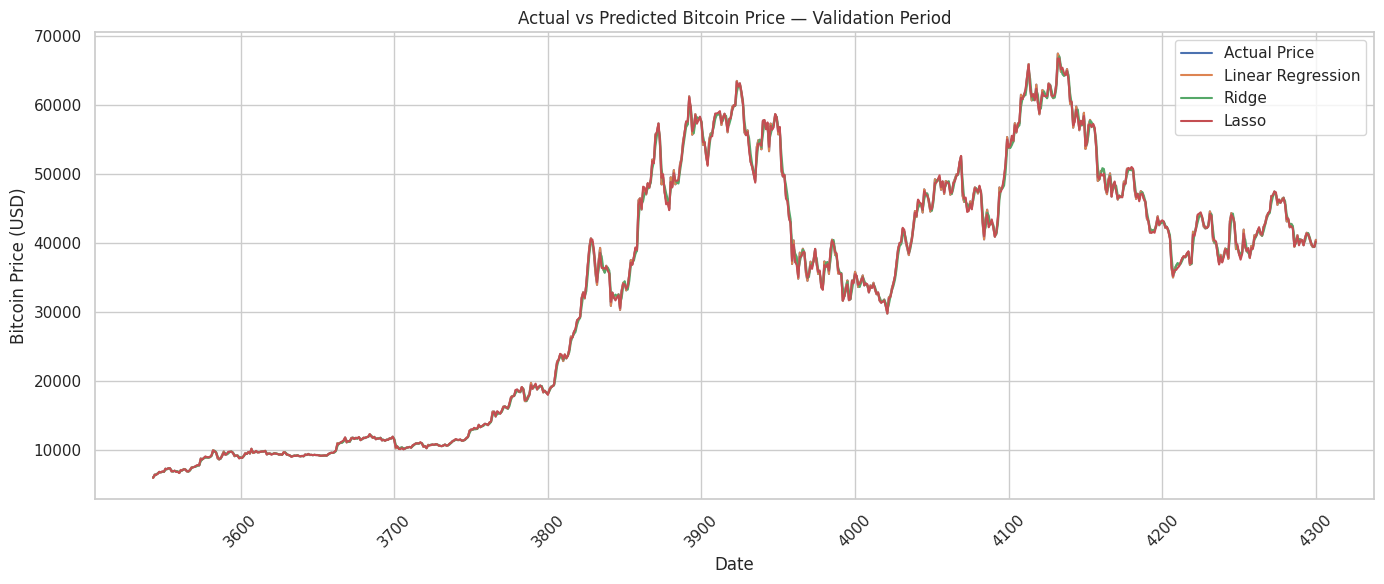

In [16]:
# Create a new figure.
plt.figure(figsize=(14, 6))

# Plot the actual Bitcoin price.
plt.plot(validation_data.index, y_validation, label="Actual Price")

# Plot Linear Regression predictions.
plt.plot(validation_data.index, linear_validation_prediction, label="Linear Regression")

# Plot Ridge predictions.
plt.plot(validation_data.index, ridge_validation_prediction, label="Ridge")

# Plot Lasso predictions.
plt.plot(validation_data.index, lasso_validation_prediction, label="Lasso")

# Add a title.
plt.title("Actual vs Predicted Bitcoin Price — Validation Period")

# Label the x-axis.
plt.xlabel("Date")

# Label the y-axis.
plt.ylabel("Bitcoin Price (USD)")

# Display the legend.
plt.legend()

# Rotate the date labels.
plt.xticks(rotation=45)

# Adjust the layout.
plt.tight_layout()

# Display the chart.
plt.show()


# 25. Test the Selected Model

After comparing models using the validation data, we select the model with the lowest validation MAE.

Then we evaluate that selected model on the **test data**, which it has not seen before.

This is an important principle:

> **Do not choose the final model using the test set.**

The test set should be kept for the final evaluation.


In [17]:
# Find the model name with the smallest validation MAE.
best_model_name = results.iloc[0]["Model"]

# Print the selected model.
print("Selected model based on validation MAE:", best_model_name)


Selected model based on validation MAE: Linear Regression


In [18]:
# Predict the testing period using each model.
linear_test_prediction = linear_model.predict(X_test)

# Apply the training scaler to the testing features.
X_test_scaled = scaler.transform(X_test)

# Predict the testing period with Ridge.
ridge_test_prediction = ridge_model.predict(X_test_scaled)

# Predict the testing period with Lasso.
lasso_test_prediction = lasso_model.predict(X_test_scaled)

# Store the predictions in a dictionary.
test_predictions = {
    "Linear Regression": linear_test_prediction,
    "Ridge Regression": ridge_test_prediction,
    "Lasso Regression": lasso_test_prediction
}

# Get the predictions from the selected model.
best_test_prediction = test_predictions[best_model_name]

# Calculate the final test MAE.
test_mae = mean_absolute_error(y_test, best_test_prediction)

# Calculate the final test RMSE.
test_rmse = np.sqrt(mean_squared_error(y_test, best_test_prediction))

# Calculate the final test R-squared.
test_r2 = r2_score(y_test, best_test_prediction)

# Print the final test MAE.
print("Final Test MAE:", test_mae)

# Print the final test RMSE.
print("Final Test RMSE:", test_rmse)

# Print the final test R-squared.
print("Final Test R²:", test_r2)


Final Test MAE: 1.871701938506461e-05
Final Test RMSE: 2.080767326754826e-05
Final Test R²: 1.0


# 26. Retrain the Selected Model Using All Available Historical Data

Now we want to forecast the future.

For a practical forecasting demonstration, we can retrain the selected model using all available historical observations before the forecast date.

This gives the model access to more historical information.

### Important distinction

This step is for **future forecasting**.

The earlier test evaluation remains our estimate of out-of-sample performance.


In [19]:
# Create the complete feature matrix.
X_all = model_data[features]

# Create the complete target vector.
y_all = model_data[target]

# Create a fresh StandardScaler for the final model.
final_scaler = StandardScaler()

# Scale all features for Ridge or Lasso.
X_all_scaled = final_scaler.fit_transform(X_all)

# Choose the appropriate final model.
if best_model_name == "Linear Regression":

    # Create a fresh Linear Regression model.
    final_model = LinearRegression()

    # Train the model using the original feature scale.
    final_model.fit(X_all, y_all)

elif best_model_name == "Ridge Regression":

    # Create a fresh Ridge model.
    final_model = Ridge(alpha=1.0)

    # Train Ridge using scaled features.
    final_model.fit(X_all_scaled, y_all)

else:

    # Create a fresh Lasso model.
    final_model = Lasso(alpha=0.01, max_iter=10000)

    # Train Lasso using scaled features.
    final_model.fit(X_all_scaled, y_all)

# Print the model that will be used for forecasting.
print("Final forecasting model:", best_model_name)


Final forecasting model: Linear Regression


# 27. Predict the Next 7 Trading Days

We now move into the future.

### Forecasting idea

Day 1:

**Latest information → Day 1 prediction**

Day 2:

**Updated information → Day 2 prediction**

Day 3:

**Updated information → Day 3 prediction**

...and so on.

We use the previous prediction to construct future lag features.

### Important limitation

`pandas` BusinessDay handles weekdays but does not automatically know Indonesian Stock Exchange holidays.

Therefore, the dates below are **weekday-based forecast dates**, not an official IDX trading calendar.


In [20]:
# Create a copy of the historical data for recursive forecasting.
forecast_history = data.copy()

# Create an empty list for forecast dates.
forecast_dates = []

# Create an empty list for forecast prices.
forecast_prices = []

# Start from the latest available date.
current_date = forecast_history[date_column].max()

# Repeat the forecasting process seven times.
for step in range(1, 8):

    # Move forward by one business day.
    next_date = current_date + pd.offsets.BDay(1)

    # Get the most recent price from the forecast history.
    latest_price = float(forecast_history[price_col].iloc[-1])

    # Get the price one observation before the latest price.
    lag_1_value = float(forecast_history[price_col].iloc[-1])

    # Get the price two observations before the latest price.
    lag_2_value = float(forecast_history[price_col].iloc[-2])

    # Get the price three observations before the latest price.
    lag_3_value = float(forecast_history[price_col].iloc[-3])

    # Calculate the latest three-observation moving average.
    ma_3_value = float(forecast_history[price_col].tail(3).mean())

    # Calculate the latest seven-observation moving average.
    ma_7_value = float(forecast_history[price_col].tail(7).mean())

    # Calculate the latest return.
    return_value = float(forecast_history[price_col].pct_change().iloc[-1])

    # Create a dictionary containing the future features.
    future_features = {
        "lag_1": lag_1_value,
        "lag_2": lag_2_value,
        "lag_3": lag_3_value,
        "ma_3": ma_3_value,
        "ma_7": ma_7_value,
        "return_1": return_value
    }

    # Add the latest volume if volume is one of our features.
    if volume_col is not None and volume_col in features:

        # Use the latest available volume as a simple future assumption.
        future_features[volume_col] = float(forecast_history[volume_col].iloc[-1])

    # Convert the feature dictionary into a one-row DataFrame.
    future_X = pd.DataFrame([future_features])[features]

    # Prepare the feature data according to the selected model.
    if best_model_name == "Linear Regression":

        # Use the original feature values for Linear Regression.
        prediction_input = future_X

    else:

        # Scale the future features using the final training scaler.
        prediction_input = final_scaler.transform(future_X)

    # Predict the next Bitcoin closing price.
    next_price = float(final_model.predict(prediction_input)[0])

    # Save the forecast date.
    forecast_dates.append(next_date)

    # Save the forecast price.
    forecast_prices.append(next_price)

    # Create a new row representing the predicted future observation.
    future_row = {column: np.nan for column in forecast_history.columns}

    # Store the predicted date.
    future_row[date_column] = next_date

    # Store the predicted price.
    future_row[price_col] = next_price

    # Store the latest volume if available.
    if volume_col is not None:

        # Carry forward the latest volume as a simple assumption.
        future_row[volume_col] = forecast_history[volume_col].iloc[-1]

    # Add the predicted row to the forecast history.
    forecast_history = pd.concat([forecast_history, pd.DataFrame([future_row])], ignore_index=True)

    # Move the current date forward.
    current_date = next_date

# Create a DataFrame containing the seven forecasts.
forecast = pd.DataFrame({
    "Date": forecast_dates,
    "Predicted_Close": forecast_prices
})

# Display the seven-day forecast.
display(forecast)


,Date,Predicted_Close
0,2024-05-23,71418.169977
1,2024-05-24,70104.399976
2,2024-05-27,69224.989977
3,2024-05-28,71418.169954
4,2024-05-29,70104.399953
5,2024-05-30,69224.989954
6,2024-05-31,71418.169932


# 28. Visualize the 7-Day Forecast

Now we combine:

**Historical Bitcoin price + predicted future prices**

This gives us a simple visual representation of the forecast.


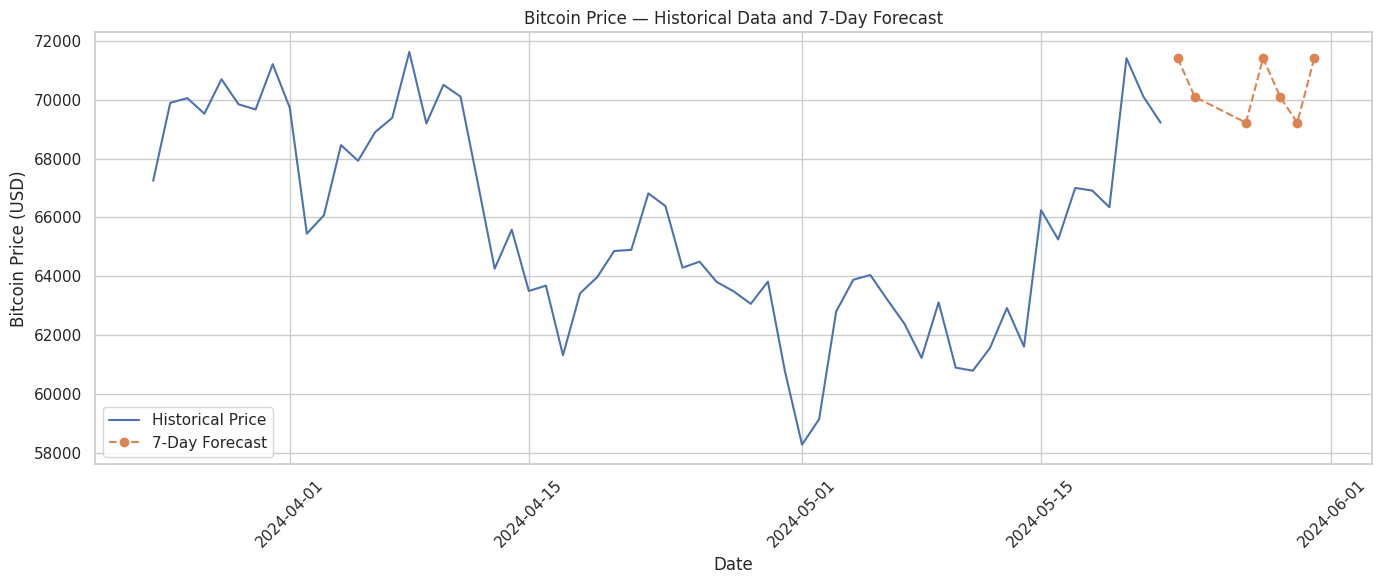

In [21]:
# Create a new figure.
plt.figure(figsize=(14, 6))

# Plot the most recent historical prices.
plt.plot(data[date_column].tail(60), data[price_col].tail(60), label="Historical Price")

# Plot the seven future predictions.
plt.plot(forecast["Date"], forecast["Predicted_Close"], marker="o", linestyle="--", label="7-Day Forecast")

# Add a title.
plt.title("Bitcoin Price — Historical Data and 7-Day Forecast")

# Label the x-axis.
plt.xlabel("Date")

# Label the y-axis.
plt.ylabel("Bitcoin Price (USD)")

# Rotate date labels.
plt.xticks(rotation=45)

# Display the legend.
plt.legend()

# Adjust the layout.
plt.tight_layout()

# Display the chart.
plt.show()


# 29. Save the Forecast

We can save the forecast as a CSV file so students can open it in Excel or use it in another analysis.


In [22]:
# Save the seven-day forecast as a CSV file.
forecast.to_csv("bitcoin_7_day_forecast.csv", index=False)

# Print a confirmation message.
print("Forecast saved as bitcoin_7_day_forecast.csv")


Forecast saved as bitcoin_7_day_forecast.csv


# Student Interpretation Exercise

Look at the final model results and the seven-day forecast.

Answer the following questions:

### 1. Model Performance
Which model had the lowest validation MAE?

### 2. Test Performance
How large was the selected model's test MAE?

### 3. Forecast
What is the predicted Bitcoin price for each of the next seven forecast days?

### 4. Economic Interpretation
Does the model predict:
- Increasing prices?
- Decreasing prices?
- Relatively stable prices?

### 5. Critical Thinking
Why might a simple Linear Regression model struggle to predict Bitcoin prices?

Think about:
- Market volatility
- Unexpected news
- Investor sentiment
- Global economic conditions
- Regulatory changes
- Nonlinear relationships
- Information that is not included in the dataset

### 6. Important Question

> **Does a good historical prediction score guarantee that the future Bitcoin price will be predicted accurately?**

Explain your answer in 3–5 sentences.


# 30. Compare More Supervised Learning Models

So far, we have compared:

- Linear Regression
- Ridge Regression
- Lasso Regression

Now we add two nonlinear regression models:

### Decision Tree Regression
Learns prediction rules by splitting observations into smaller groups.

### Random Forest Regression
Combines many decision trees and averages their predictions.

### Why compare different models?

Different models make different assumptions.

- **Linear models** → simple and interpretable.
- **Tree-based models** → can capture nonlinear relationships.

> **A more complicated model is not automatically a better model. We compare models using unseen data.**


In [23]:
# Import DecisionTreeRegressor for decision-tree regression.
from sklearn.tree import DecisionTreeRegressor

# Import RandomForestRegressor for random-forest regression.
from sklearn.ensemble import RandomForestRegressor

# Create a Decision Tree regression model.
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)

# Train the Decision Tree using the training data.
tree_model.fit(X_train, y_train)

# Predict prices for the validation data.
tree_validation_prediction = tree_model.predict(X_validation)

# Calculate the validation MAE.
tree_mae = mean_absolute_error(y_validation, tree_validation_prediction)

# Calculate the validation RMSE.
tree_rmse = np.sqrt(mean_squared_error(y_validation, tree_validation_prediction))

# Calculate the validation R-squared.
tree_r2 = r2_score(y_validation, tree_validation_prediction)

# Print the Decision Tree results.
print("Decision Tree Validation MAE:", tree_mae)

# Print the Decision Tree RMSE.
print("Decision Tree Validation RMSE:", tree_rmse)

# Print the Decision Tree R-squared.
print("Decision Tree Validation R²:", tree_r2)


Decision Tree Validation MAE: 17447.805174614983
Decision Tree Validation RMSE: 22799.129398463487
Decision Tree Validation R²: -0.5892288149447333


In [24]:
# Create a Random Forest regression model.
forest_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)

# Train the Random Forest using the training data.
forest_model.fit(X_train, y_train)

# Predict prices for the validation data.
forest_validation_prediction = forest_model.predict(X_validation)

# Calculate the validation MAE.
forest_mae = mean_absolute_error(y_validation, forest_validation_prediction)

# Calculate the validation RMSE.
forest_rmse = np.sqrt(mean_squared_error(y_validation, forest_validation_prediction))

# Calculate the validation R-squared.
forest_r2 = r2_score(y_validation, forest_validation_prediction)

# Print the Random Forest results.
print("Random Forest Validation MAE:", forest_mae)

# Print the Random Forest RMSE.
print("Random Forest Validation RMSE:", forest_rmse)

# Print the Random Forest R-squared.
print("Random Forest Validation R²:", forest_r2)


Random Forest Validation MAE: 18010.08236678169
Random Forest Validation RMSE: 23483.76118002643
Random Forest Validation R²: -0.6861073213376285


# Understanding the Difference Between the Five Models

Before comparing the numerical results, it is important to understand **how the five models think differently**.

| Model | How does it learn? | Main purpose | Main advantage | Main limitation |
|---|---|---|---|---|
| **Linear Regression** | Fits a straight-line relationship between features and the target | Simple baseline prediction | Easy to understand and interpret | May miss nonlinear relationships |
| **Ridge Regression** | Linear Regression + **L2 regularization** | Control large coefficients | Helps when predictors are correlated and reduces overfitting | Still assumes a linear relationship |
| **Lasso Regression** | Linear Regression + **L1 regularization** | Prediction + feature selection | Can shrink some coefficients to exactly zero | A strong penalty can remove useful variables |
| **Decision Tree** | Splits observations using a sequence of rules | Capture nonlinear relationships | Easy rule-based intuition and no feature scaling required | A single tree can overfit or be unstable |
| **Random Forest** | Combines predictions from many Decision Trees | More robust nonlinear prediction | Usually more stable than one tree and captures complex patterns | More difficult to interpret |

</br>

### The easiest way to remember

**Linear Regression** → *Straight-line relationship*

**Ridge** → *Straight line + control large coefficients*

**Lasso** → *Straight line + can remove less useful features*

**Decision Tree** → *If–then rules*

**Random Forest** → *Many trees working together*

</br>

### Bitcoin example

Suppose we want to predict Bitcoin's closing price using previous price, moving averages, return, and trading volume.

- **Linear Regression:** assumes these variables have a mainly linear relationship with Bitcoin price.
- **Ridge:** keeps the linear approach but penalizes very large coefficients.
- **Lasso:** keeps the linear approach and may reduce some feature coefficients to zero.
- **Decision Tree:** learns rules such as *if previous return is high and volume is high, predict a certain price range*.
- **Random Forest:** creates many different trees and combines their predictions.

> **Important:** A more complicated model is **not automatically a better model**. We must compare performance on unseen data.

The goal is not simply to find the most complicated algorithm. The goal is to find a model that provides useful predictive performance while considering interpretability and the economic question.

# Model Difference at a Glance

Think of the five models as five different strategies for finding a relationship between **X (features)** and **y (Bitcoin price)**:

### 1. Linear Models

**Linear → Ridge → Lasso**

These three models are based on a linear relationship. Ridge and Lasso modify ordinary Linear Regression through regularization.

### 2. Tree-Based Models

**Decision Tree → Random Forest**

These models can capture nonlinear patterns. A Decision Tree uses one tree of rules, while Random Forest combines many trees.


</br>

### Key takeaway

> **Start simple → add regularization → try nonlinear models → compare using unseen data.**

# 31. Compare All Five Models

We now compare:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Decision Tree Regression
5. Random Forest Regression

### Evaluation

For **MAE** and **RMSE**:

> Lower is better.

For **R²**:

> Higher is better.

We use the **validation set** for model selection.

The test set remains untouched until final evaluation.


In [25]:
# Create a table containing validation results for all five models.
all_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        tree_r2,
        forest_r2
    ]
})

# Sort models from lowest MAE to highest MAE.
all_results = all_results.sort_values("MAE").reset_index(drop=True)

# Display the complete comparison table.
display(all_results)


,Model,MAE,RMSE,R2
0,Linear Regression,0.000020,0.000023,1.000000
1,Lasso Regression,162.835061,237.978240,0.999827
2,Ridge Regression,411.188237,633.376836,0.998773
3,Decision Tree,17447.805175,22799.129398,-0.589229
4,Random Forest,18010.082367,23483.761180,-0.686107


# 32. Visual Comparison of Model Performance

MAE is especially intuitive for this class.

> **MAE tells us the average size of the prediction error in the same unit as Bitcoin price.**

For example, an MAE of 500 means that predictions are, on average, about **$500 away from the actual price**.


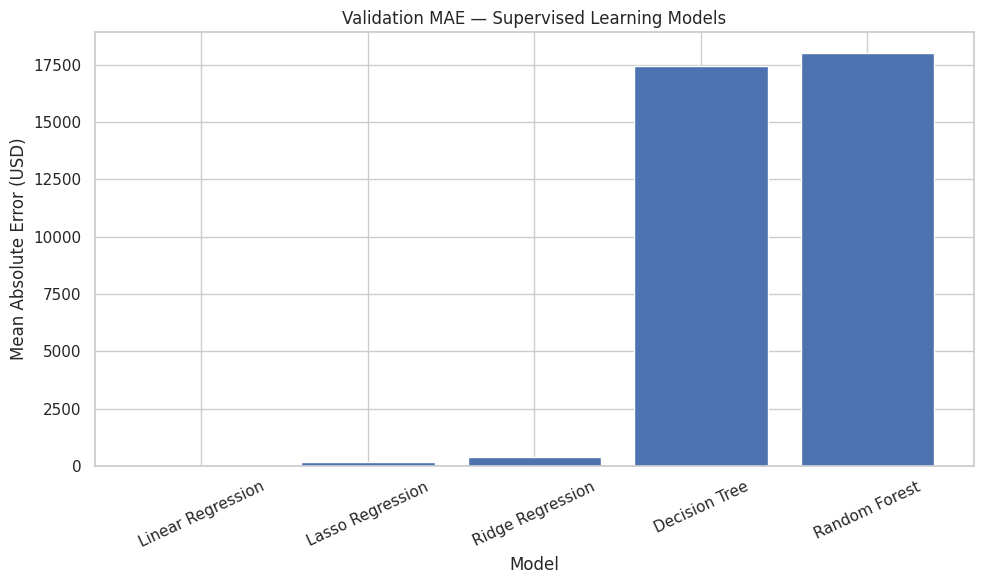

In [26]:
# Create a new figure.
plt.figure(figsize=(10, 6))

# Draw a bar chart of validation MAE.
plt.bar(all_results["Model"], all_results["MAE"])

# Add a title.
plt.title("Validation MAE — Supervised Learning Models")

# Label the x-axis.
plt.xlabel("Model")

# Label the y-axis.
plt.ylabel("Mean Absolute Error (USD)")

# Rotate model names for readability.
plt.xticks(rotation=25)

# Adjust the layout.
plt.tight_layout()

# Display the chart.
plt.show()


# 33. Test All Models on Unseen Data

The test dataset represents observations that were not used to train the models.

Now we check whether the models continue to perform well on unseen observations.

> **Good validation performance does not guarantee good test performance.**

This is why we need a separate test set.


In [27]:
# Predict the test period using Linear Regression.
linear_test_prediction = linear_model.predict(X_test)

# Predict the test period using Ridge Regression.
ridge_test_prediction = ridge_model.predict(X_test_scaled)

# Predict the test period using Lasso Regression.
lasso_test_prediction = lasso_model.predict(X_test_scaled)

# Predict the test period using the Decision Tree.
tree_test_prediction = tree_model.predict(X_test)

# Predict the test period using the Random Forest.
forest_test_prediction = forest_model.predict(X_test)

# Store predictions from all five models.
all_test_predictions = {
    "Linear Regression": linear_test_prediction,
    "Ridge Regression": ridge_test_prediction,
    "Lasso Regression": lasso_test_prediction,
    "Decision Tree": tree_test_prediction,
    "Random Forest": forest_test_prediction
}

# Create an empty list for the test results.
test_results_list = []

# Loop through every model.
for model_name, predictions in all_test_predictions.items():

    # Calculate the model's test MAE.
    model_mae = mean_absolute_error(y_test, predictions)

    # Calculate the model's test RMSE.
    model_rmse = np.sqrt(mean_squared_error(y_test, predictions))

    # Calculate the model's test R-squared.
    model_r2 = r2_score(y_test, predictions)

    # Store the model results.
    test_results_list.append({
        "Model": model_name,
        "MAE": model_mae,
        "RMSE": model_rmse,
        "R2": model_r2
    })

# Convert the results into a DataFrame.
test_results = pd.DataFrame(test_results_list)

# Sort models from lowest test MAE to highest test MAE.
test_results = test_results.sort_values("MAE").reset_index(drop=True)

# Display the test results.
display(test_results)


,Model,MAE,RMSE,R2
0,Linear Regression,0.000019,0.000021,1.000000
1,Lasso Regression,108.800956,159.164419,0.999880
2,Ridge Regression,280.410147,460.096862,0.998993
3,Decision Tree,13489.527510,19651.974968,-0.836723
4,Random Forest,14269.269050,20260.290980,-0.952193


# 34. Validation vs Test Performance

Compare the validation and test results.

### What should students look for?

If a model performs very well on training/validation data but much worse on unseen data, it may be **overfitting**.

If validation and test performance are reasonably similar, the model may generalize better.

### Important Economics/Data Science lesson

> **Model evaluation is about performance on unseen data, not just how well a model fits historical observations.**


In [28]:
# Add a label showing that these are validation results.
validation_table = all_results.copy()

# Create a dataset column for the validation results.
validation_table["Dataset"] = "Validation"

# Add a label showing that these are test results.
test_table = test_results.copy()

# Create a dataset column for the test results.
test_table["Dataset"] = "Test"

# Combine validation and test results.
comparison_table = pd.concat([validation_table, test_table], ignore_index=True)

# Reorder the columns for readability.
comparison_table = comparison_table[["Dataset", "Model", "MAE", "RMSE", "R2"]]

# Display the combined comparison.
display(comparison_table)


,Dataset,Model,MAE,RMSE,R2
0,Validation,Linear Regression,0.000020,0.000023,1.000000
1,Validation,Lasso Regression,162.835061,237.978240,0.999827
2,Validation,Ridge Regression,411.188237,633.376836,0.998773
3,Validation,Decision Tree,17447.805175,22799.129398,-0.589229
4,Validation,Random Forest,18010.082367,23483.761180,-0.686107
5,Test,Linear Regression,0.000019,0.000021,1.000000
6,Test,Lasso Regression,108.800956,159.164419,0.999880
7,Test,Ridge Regression,280.410147,460.096862,0.998993
8,Test,Decision Tree,13489.527510,19651.974968,-0.836723
9,Test,Random Forest,14269.269050,20260.290980,-0.952193


# 35. Choose the Model for the 7-Day Forecast

For the educational forecasting exercise, we select the model with the **lowest validation MAE**.

### But remember

The best validation score does not mean:

> "This model can accurately predict Bitcoin."

It only means:

> "Among the models we tested, this model performed best on our chosen validation period."

This distinction is very important in financial forecasting.


In [29]:
# Select the model with the lowest validation MAE.
best_model_name = all_results.iloc[0]["Model"]

# Print the selected model.
print("Selected model:", best_model_name)

# Create a dictionary containing validation predictions from all models.
validation_predictions = {
    "Linear Regression": linear_validation_prediction,
    "Ridge Regression": ridge_validation_prediction,
    "Lasso Regression": lasso_validation_prediction,
    "Decision Tree": tree_validation_prediction,
    "Random Forest": forest_validation_prediction
}

# Select the validation predictions from the chosen model.
best_validation_prediction = validation_predictions[best_model_name]

# Print the selected model's validation MAE.
print("Validation MAE:", all_results.iloc[0]["MAE"])


Selected model: Linear Regression
Validation MAE: 1.9614564059571365e-05


# 36. Updated Student Exercise

### Task 1 — Model Comparison
Which model has the lowest validation MAE? Which model is the best? And explain the reasons!

### Task 2 — Validation vs Test
Does the same model also perform best on the test set?

### Task 3 — Linear vs Nonlinear
Compare Linear Regression with Decision Tree and Random Forest.

What differences do you observe?

### Task 4 — Interpretability
Which model would be easiest to explain to an Economics audience?

### Task 5 — Critical Thinking

> Why might a more complicated model perform better than Linear Regression on some datasets, but not on every dataset?

### Task 6 — Economic Interpretation

> What economic information is missing from our Bitcoin dataset that could potentially improve the prediction?


# Final Takeaways

### Supervised Learning
Learns from examples where the target is already known.

### Regression
Predicts a numerical target.

### Linear Regression
Provides a simple and interpretable baseline.

### Ridge
Adds L2 regularization to reduce overly large coefficients.

### Lasso
Adds L1 regularization and can shrink some coefficients to zero.

### Training / Validation / Testing
Help us evaluate models without allowing future information to leak into the past.

### Time-Series Rule
> **Never randomly shuffle chronological economic data when doing a forecasting task.**

### Bitcoin Forecasting
Linear, Ridge, and Lasso can demonstrate the mechanics of supervised regression, but Bitcoin prices are influenced by many factors that are not contained in this simple dataset.

---

</br>

# Possible examples:
- Interest rates
- Inflation
- Exchange rates
- Stock-market conditions
- Investor sentiment
- Regulation
- News
- Macroeconomic indicators


# References & Data Sources

### Dataset
**Kaggle — Bitcoin Historical Dataset**  
https://www.kaggle.com/datasets/priyamchoksi/bitcoin-historical-prices-and-activity-2010-2024

### Recommended References

1. James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer.
2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly.
3. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly.
4. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
5. scikit-learn documentation: https://scikit-learn.org/stable/
6. pandas documentation: https://pandas.pydata.org/docs/
7. Google Colab: https://colab.research.google.com/

### Important Disclaimer

The seven-day Bitcoin forecast is an **educational demonstration** of supervised regression.

It is not financial advice, and the forecast should not be interpreted as a reliable prediction of future cryptocurrency prices.
